<a href="https://colab.research.google.com/github/Manisha-Purushothaman/linkedin-job-nlp/blob/main/Final_Project_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Name : Manisha Purushothaman**

**Student ID : 4108IDJE**
# Skill Extraction and Job Role Classification from LinkedIn Job Postings Using NLP and Transformer Models

## Project Objective

This project uses the LinkedIn Job Postings 2023–2024 dataset for an NLP project on skill extraction and job role classification. The project cleans and anonymises job descriptions, creates rule-based job role labels, extracts skills using an ESCO-style skill dictionary, and produces summary reports and charts for further modelling.

## Research Question

How effectively can traditional machine learning and transformer-based NLP models classify job roles and extract important skills from LinkedIn job descriptions?

## Dataset

The dataset used in this project is the LinkedIn Job Postings 2023–2024 dataset from Kaggle. It contains job titles, descriptions, locations, salary-related fields, work type and company-related information. The raw dataset is cleaned before analysis because job descriptions may contain privacy-risk information such as emails, phone numbers, recruiter contact details and URLs.

Dataset: https://www.kaggle.com/datasets/arshkon/linkedin-job-postings?resource=download

In [20]:
# Install required packages
!pip install -q kagglehub[pandas-datasets] pandas numpy matplotlib seaborn

In [21]:
#import required libraries
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import warnings
import os # Import os module to list directory contents
warnings.filterwarnings('ignore')

print("Loading dataset from Kaggle...")
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arshkon/linkedin-job-postings",
    "postings.csv"
)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loading dataset from Kaggle...
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Loaded: 123,849 rows × 31 columns


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [22]:
import os
import pandas as pd

# Create reports folder
os.makedirs("reports", exist_ok=True)
#── 2.1 Basic info
print("=" * 55)
print("DATASET AUDIT REPORT")
print("=" * 55)

print(f"Shape          : {df.shape}")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

# ── 2.2 Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

audit = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
})

audit_missing = audit[audit["missing_count"] > 0].sort_values(
    "missing_%",
    ascending=False
)

display(audit_missing)

# Save missing value report
audit_missing.to_csv("reports/missing_values_report.csv")

print("Saved → reports/missing_values_report.csv")

DATASET AUDIT REPORT
Shape          : (123849, 31)
Memory usage   : 973.2 MB



,missing_count,missing_%
closed_time,122776,99.13
skills_desc,121410,98.03
med_salary,117569,94.93
remote_allowed,108603,87.69
applies,100529,81.17
min_salary,94056,75.94
max_salary,94056,75.94
pay_period,87776,70.87
compensation_type,87776,70.87
normalized_salary,87776,70.87


Saved → reports/missing_values_report.csv


In [23]:
# ── 2.3 Column dtypes overview
print("COLUMN DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\nKey columns sample:")

key_cols = [
    c for c in [
        "title",
        "description",
        "location",
        "max_salary",
        "formatted_work_type",
        "formatted_experience_level"
    ]
    if c in df.columns
]

print(df[key_cols].head(3).to_string())

COLUMN DATA TYPES
job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
original_listed_time          float64
remote_allowed                float64
job_posting_url                object
application_url                object
application_type               object
expiry                        float64
closed_time                   float64
formatted_experience_level     object
skills_desc                    object
listed_time                   float64
posting_domain                 object
sponsored                       int64
work_type                      o

In [24]:
# ── 2.4 Handle missing values based on column purpose

import numpy as np
import pandas as pd

# Make a copy so original df is unchanged
clean_df = df.copy()

print("Original shape:", clean_df.shape)

# 1. Drop columns that are risky, weak, or not useful for this NLP project
drop_cols = [
    "application_url",      # privacy risk
    "job_posting_url",      # traceable URL
    "job_id",               # trace identifier
    "company_id",           # trace identifier
    "fips",                 # not needed for NLP
    "closed_time",          # very high missing values
    "sponsored",            # zero variance
    "skills_desc",          # very high missing values
    "med_salary"            # very high missing values
]

drop_cols_existing = [col for col in drop_cols if col in clean_df.columns]
clean_df = clean_df.drop(columns=drop_cols_existing)

print("Dropped columns:", drop_cols_existing)
print("Shape after dropping columns:", clean_df.shape)


# 2. Remove rows where description is missing
if "description" in clean_df.columns:
    clean_df = clean_df.dropna(subset=["description"])

    # Remove very short descriptions because they are not useful for NLP
    clean_df = clean_df[clean_df["description"].astype(str).str.len() >= 50]

print("Shape after removing missing/short descriptions:", clean_df.shape)


# 3. Fill missing categorical/text metadata with 'Unknown'
categorical_fill_cols = [
    "posting_domain",
    "formatted_experience_level",
    "company_name",
    "zip_code",
    "pay_period",
    "currency",
    "compensation_type"
]

for col in categorical_fill_cols:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna("Unknown")


# 4. Fill missing numeric columns with median
numeric_median_cols = [
    "views",
    "applies",
    "min_salary",
    "max_salary",
    "normalized_salary",
    "remote_allowed"
]

for col in numeric_median_cols:
    if col in clean_df.columns:
        median_value = clean_df[col].median()
        clean_df[col] = clean_df[col].fillna(median_value)


# 5. Check remaining missing values
remaining_missing = clean_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

if remaining_missing.empty:
    print("No remaining missing values found.")
else:
    print(remaining_missing)

print("\nFinal shape after missing value handling:", clean_df.shape)

Original shape: (123849, 31)
Dropped columns: ['application_url', 'job_posting_url', 'job_id', 'company_id', 'fips', 'closed_time', 'sponsored', 'skills_desc', 'med_salary']
Shape after dropping columns: (123849, 22)
Shape after removing missing/short descriptions: (123782, 22)
No remaining missing values found.

Final shape after missing value handling: (123782, 22)


3. PII Detection & Removal (GDPR Compliance)

In [25]:
import re
import pandas as pd
import os

os.makedirs("reports", exist_ok=True)

# Regex patterns for PII
EMAIL_PATTERN = r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}'
PHONE_PATTERN = r'(\+?\d[\d\s\-().]{7,}\d)'
URL_PATTERN = r'https?://[^\s<>"]+|www\.[^\s<>"]+'
RECRUITER_PATTERN = r'\b(?:contact|reach out to|email|call|apply to)\s+[A-Z][a-z]+\s+[A-Z][a-z]+\b'

def detect_pii(text):
    """Detect emails, phone numbers, URLs and recruiter contact phrases."""
    if not isinstance(text, str):
        return {
            "emails": [],
            "phones": [],
            "urls": [],
            "recruiters": []
        }

    return {
        "emails": re.findall(EMAIL_PATTERN, text),
        "phones": re.findall(PHONE_PATTERN, text),
        "urls": re.findall(URL_PATTERN, text),
        "recruiters": re.findall(RECRUITER_PATTERN, text)
    }

def remove_pii(text):
    """Remove or mask PII from text."""
    if not isinstance(text, str):
        return text

    text = re.sub(EMAIL_PATTERN, "[EMAIL REMOVED]", text)
    text = re.sub(URL_PATTERN, "[URL REMOVED]", text)
    text = re.sub(PHONE_PATTERN, "[PHONE REMOVED]", text)
    text = re.sub(RECRUITER_PATTERN, "[CONTACT REMOVED]", text)

    return text.strip()

# PII audit on full dataset description column
pii_found = df["description"].dropna().apply(detect_pii)

emails_count = pii_found.apply(lambda x: len(x["emails"])).sum()
phones_count = pii_found.apply(lambda x: len(x["phones"])).sum()
urls_count = pii_found.apply(lambda x: len(x["urls"])).sum()
recruiters_count = pii_found.apply(lambda x: len(x["recruiters"])).sum()

pii_summary = pd.DataFrame({
    "PII Type": ["Emails", "Phone numbers", "URLs", "Recruiter contact phrases"],
    "Count Found": [emails_count, phones_count, urls_count, recruiters_count]
})
display(pii_summary)

pii_summary.to_csv("reports/pii_audit_summary.csv", index=False)

print("Saved → reports/pii_audit_summary.csv")
clean_df["description_clean"] = clean_df["description"].apply(remove_pii)

print("PII removed from description column.")

,PII Type,Count Found
0,Emails,18574
1,Phone numbers,20927
2,URLs,29868
3,Recruiter contact phrases,2699


Saved → reports/pii_audit_summary.csv
PII removed from description column.


In [26]:
# ── Apply PII removal to text columns

df_clean = clean_df.copy()

# Create cleaned description column
df_clean["description_clean"] = df_clean["description"].apply(remove_pii)

# Clean only the text columns needed for modelling
TEXT_COLS = [c for c in ["description_clean", "title"] if c in df_clean.columns]

for col in TEXT_COLS:
    print(f"Cleaning column: {col} ...")
    df_clean[col] = df_clean[col].apply(remove_pii)

# Drop rows with missing title or cleaned description
df_clean = df_clean.dropna(subset=["title", "description_clean"])

# Drop full duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean):,} duplicate rows")

# Remove raw description before final save
df_clean = df_clean.drop(columns=["description"], errors="ignore")

print(f"Final shape after cleaning: {df_clean.shape}")

Cleaning column: description_clean ...
Cleaning column: title ...
Removed 304 duplicate rows
Final shape after cleaning: (123478, 22)


In [27]:
import pandas as pd
import os

os.makedirs("reports", exist_ok=True)

cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Original dataset",
        "Risky / weak columns removed",
        "Missing and short descriptions removed",
        "Duplicate rows removed",
        "Final cleaned dataset"
    ],
    "Result": [
        "123,849 rows, 31 columns",
        "9 columns removed",
        "67 rows removed",
        "304 duplicate rows removed",
        f"{df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns"
    ],
    "Reason": [
        "Raw LinkedIn job postings dataset",
        "Privacy risk, traceability, high missing values or low value",
        "Descriptions are required for NLP modelling",
        "Duplicate postings can bias model training",
        "Ready for EDA, skill extraction and modelling"
    ]
})

display(cleaning_summary)

cleaning_summary.to_csv("reports/data_cleaning_summary.csv", index=False)

print("Saved → reports/data_cleaning_summary.csv")

,Cleaning Step,Result,Reason
0,Original dataset,"123,849 rows, 31 columns",Raw LinkedIn job postings dataset
1,Risky / weak columns removed,9 columns removed,"Privacy risk, traceability, high missing value..."
2,Missing and short descriptions removed,67 rows removed,Descriptions are required for NLP modelling
3,Duplicate rows removed,304 duplicate rows removed,Duplicate postings can bias model training
4,Final cleaned dataset,"123,478 rows, 22 columns","Ready for EDA, skill extraction and modelling"


Saved → reports/data_cleaning_summary.csv


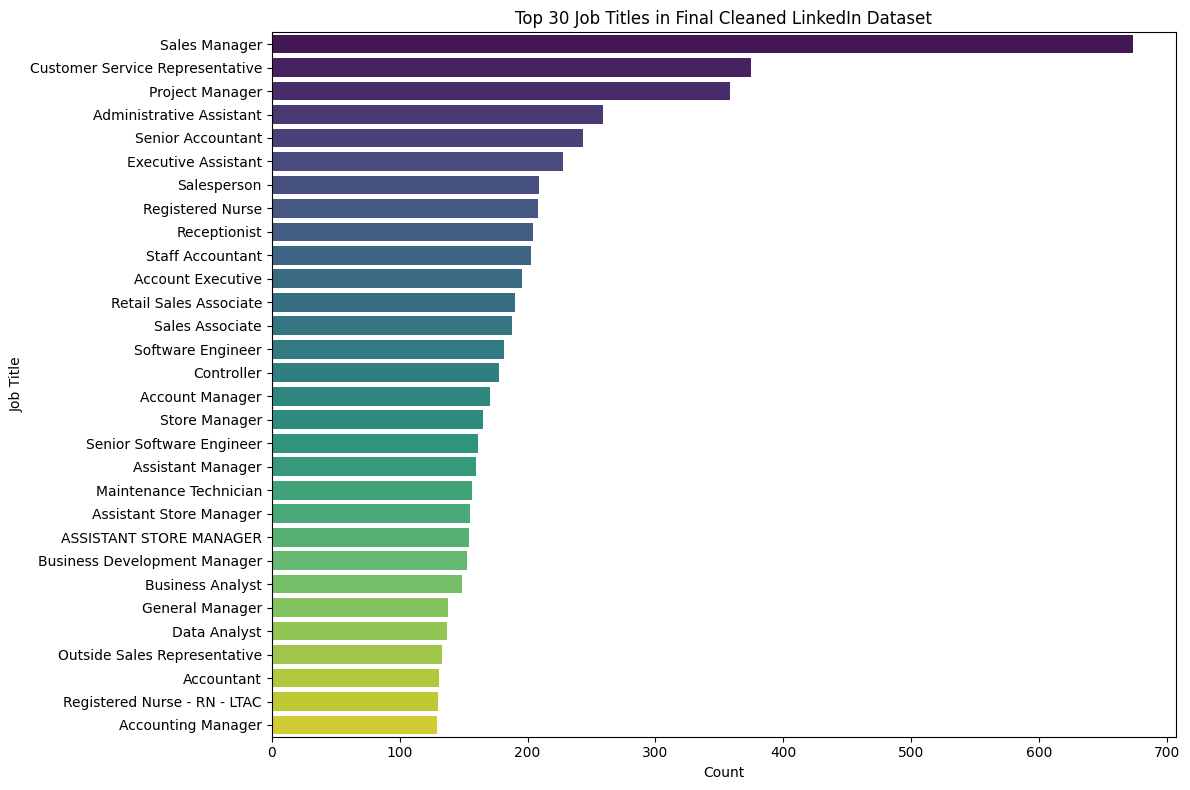

Saved → reports/top_job_titles_cleaned.png


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("reports", exist_ok=True)

top_titles = df_clean["title"].value_counts().head(30)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")
plt.title("Top 30 Job Titles in Final Cleaned LinkedIn Dataset")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.tight_layout()

plt.savefig("reports/top_job_titles_cleaned.png", dpi=150)
plt.show()

print("Saved → reports/top_job_titles_cleaned.png")

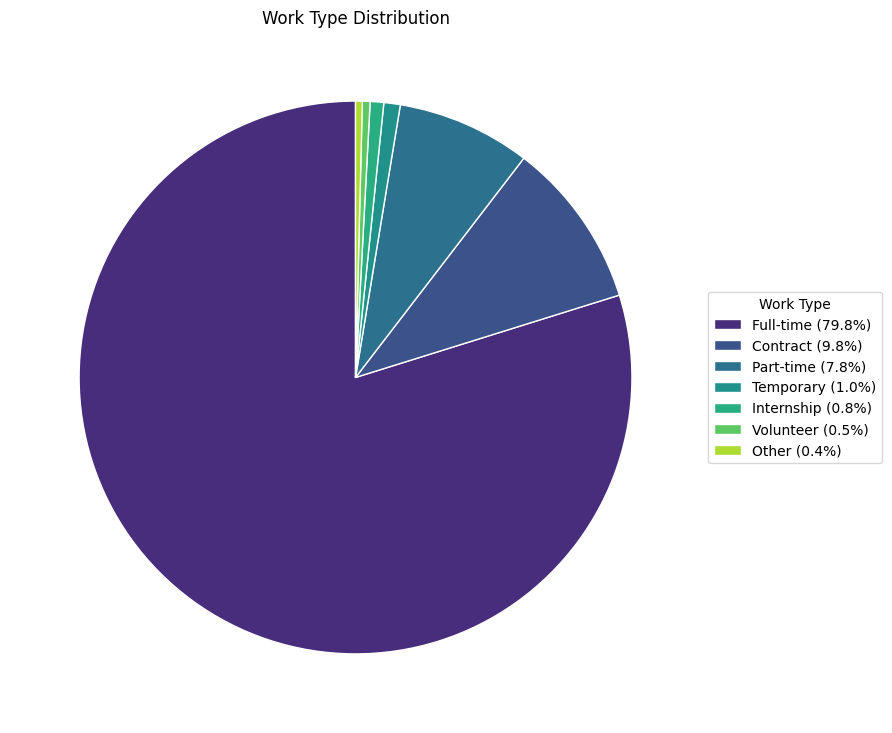

Saved → reports/work_type_distribution.png


In [29]:
# Work type distribution (Pie Chart - percentages in legend only)

work_counts = df_clean["formatted_work_type"].value_counts()
percentages = (work_counts / work_counts.sum() * 100).round(1)

plt.figure(figsize=(9, 9))
colors = sns.color_palette("viridis", len(work_counts))

wedges, _ = plt.pie(work_counts.values,labels=None,startangle=90,colors=colors,wedgeprops={'edgecolor': 'white', 'linewidth': 1})

# Build legend labels with category name + percentage
legend_labels = [f"{cat} ({pct}%)" for cat, pct in zip(work_counts.index, percentages)]

plt.legend(wedges,legend_labels,title="Work Type",loc="center left",bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Work Type Distribution")
plt.tight_layout()

plt.savefig("reports/work_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → reports/work_type_distribution.png")

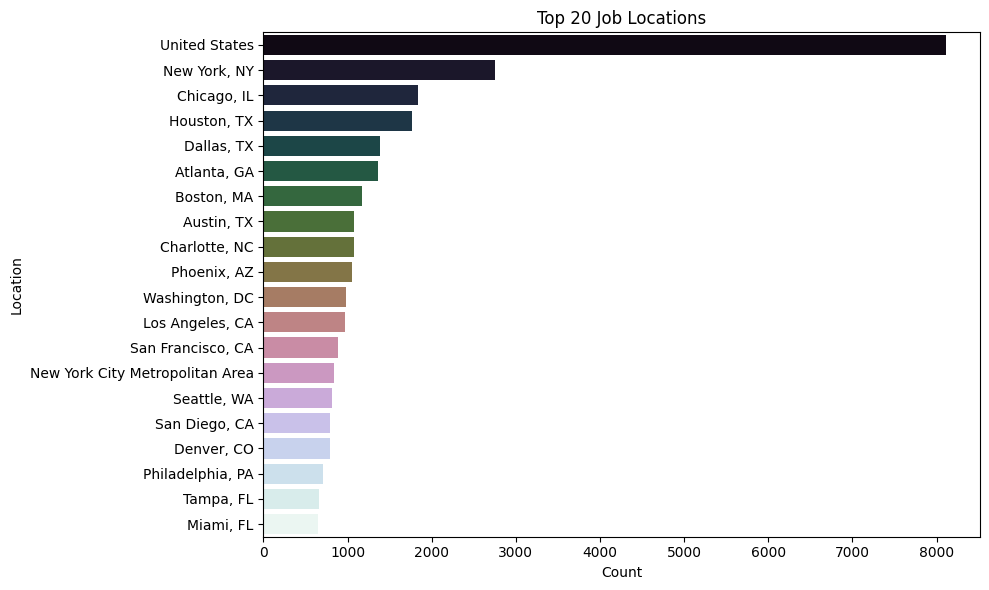

Saved → reports/top_locations.png


In [30]:
# Top 20 job locations

top_locations = df_clean["location"].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="cubehelix")
plt.title("Top 20 Job Locations")
plt.xlabel("Count")
plt.ylabel("Location")
plt.tight_layout()

plt.savefig("reports/top_locations.png", dpi=150)
plt.show()

print("Saved → reports/top_locations.png")

In [31]:
# Salary availability check

salary_cols = ["min_salary", "max_salary", "normalized_salary"]
available_salary_cols = [col for col in salary_cols if col in df_clean.columns]

salary_availability = pd.DataFrame({
    "Column": available_salary_cols,
    "Available Count": [df_clean[col].notna().sum() for col in available_salary_cols],
    "Missing Count": [df_clean[col].isna().sum() for col in available_salary_cols]
})

display(salary_availability)

salary_availability.to_csv("reports/salary_availability.csv", index=False)

print("Saved → reports/salary_availability.csv")

,Column,Available Count,Missing Count
0,min_salary,123478,0
1,max_salary,123478,0
2,normalized_salary,123478,0


Saved → reports/salary_availability.csv


In [32]:
import os

os.makedirs("processed_data", exist_ok=True)

df_clean.to_csv("processed_data/postings_cleaned.csv", index=False)

print("Saved final cleaned dataset → processed_data/postings_cleaned.csv")
print("Final cleaned shape:", df_clean.shape)

Saved final cleaned dataset → processed_data/postings_cleaned.csv
Final cleaned shape: (123478, 22)


Updated role category distribution:
role_category
Other                       17874
Healthcare                  16942
Construction & Trades        9062
Sales                        8946
Customer Support             6637
Finance & Accounting         5992
Operations                   5372
Software Engineering         5009
Education                    4275
Administrative               4177
Retail                       3744
Project Management           3140
Manufacturing                2391
Marketing                    2097
Engineering                  2029
Transportation & Driver      1980
DevOps & Cloud               1976
Food Service                 1906
Human Resources              1657
Legal                        1510
Data Analytics               1502
Quality & Compliance         1393
Architecture & Planning      1254
Banking & Insurance          1217
General Management           1166
UX/UI Design                 1092
Data Engineering             1042
Hospitality                  103

,count
title,
Delivery Specialist,57
Task Associate,42
MANAGEMENT TRAINING - ENTRY LEVEL,38
Auto Detailer,35
Technical Lead,29
...,...
"Sr Manager, Anti-Money Laundering (AML)",7
Surgical Technologist - Operating Room,7
Shift Supervisor Trainee,7


Saved → reports/top_remaining_other_titles.csv


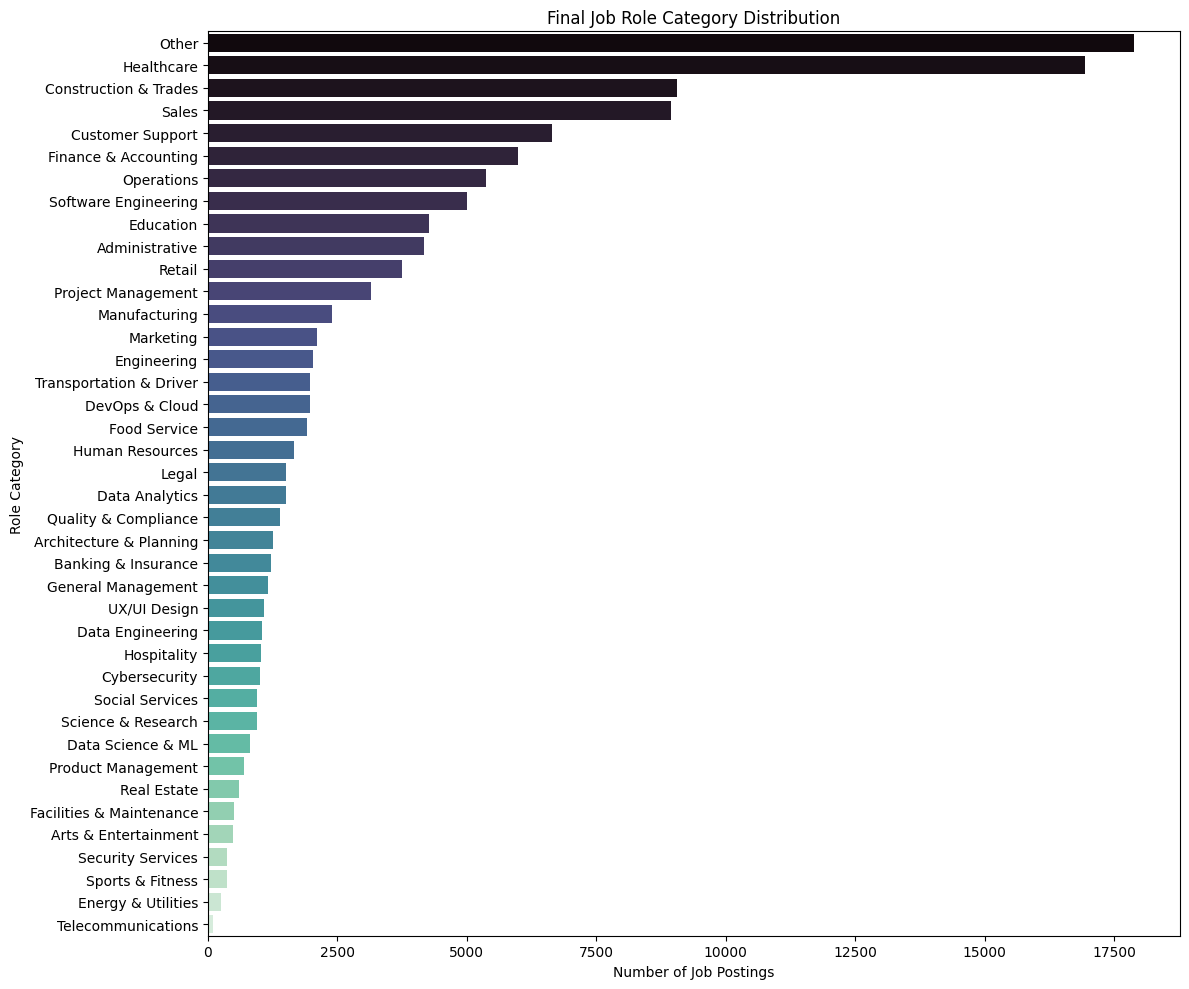

Saved → reports/role_category_distribution_final.png

Full cleaned dataset shape: (123478, 23)
Model dataset shape without Other: (105604, 23)

Model dataset role distribution:
role_category
Healthcare                  16942
Construction & Trades        9062
Sales                        8946
Customer Support             6637
Finance & Accounting         5992
Operations                   5372
Software Engineering         5009
Education                    4275
Administrative               4177
Retail                       3744
Project Management           3140
Manufacturing                2391
Marketing                    2097
Engineering                  2029
Transportation & Driver      1980
DevOps & Cloud               1976
Food Service                 1906
Human Resources              1657
Legal                        1510
Data Analytics               1502
Quality & Compliance         1393
Architecture & Planning      1254
Banking & Insurance          1217
General Management         

In [33]:
# ── Full Rule-Based Job Role Classification
# Use this after df_clean and description_clean are created

import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("reports", exist_ok=True)

# ---------------------------------------------------------
# 1. Expanded role map
# ---------------------------------------------------------

ROLE_MAP = {
    "Software Engineering": [
        "software engineer", "software developer", "developer", "programmer",
        "backend", "back end", "frontend", "front end", "full stack", "full-stack",
        "web developer", "mobile developer", "ios developer", "android developer",
        "java developer", "python developer", ".net developer", "application developer",
        "application engineer", "qa automation engineer", "test automation engineer",
        "software architect", "systems developer"
    ],

    "Data Science & ML": [
        "data scientist", "machine learning", "ml engineer", "ai engineer",
        "artificial intelligence", "deep learning", "nlp", "research scientist",
        "computer vision", "predictive modeling", "statistical modeler",
        "applied scientist"
    ],

    "Data Engineering": [
        "data engineer", "etl", "data pipeline", "big data", "spark",
        "databricks", "data platform", "warehouse engineer", "analytics engineer",
        "data modeler", "data modeller", "database developer", "database administrator",
        "dba", "data architect", "data warehouse", "snowflake developer"
    ],

    "Data Analytics": [
        "data analyst", "business analyst", "bi analyst", "business intelligence",
        "reporting analyst", "analytics analyst", "insights analyst",
        "tableau", "power bi", "report developer", "research analyst",
        "market analyst", "operations analyst"
    ],

    "DevOps & Cloud": [
        "devops", "sre", "site reliability", "cloud engineer", "cloud architect",
        "platform engineer", "infrastructure engineer", "systems engineer",
        "network engineer", "systems administrator", "system administrator",
        "linux administrator", "windows administrator", "it administrator",
        "network administrator", "kubernetes", "docker", "aws", "azure", "gcp",
        "cloud administrator"
    ],

    "Cybersecurity": [
        "security engineer", "cybersecurity", "cyber security",
        "information security", "soc analyst", "penetration tester",
        "security analyst", "security architect", "threat analyst",
        "security consultant", "identity access", "iam analyst"
    ],

    "Product Management": [
        "product manager", "product owner", "technical product manager",
        "associate product manager", "product lead", "product director"
    ],

    "Project Management": [
        "project manager", "program manager", "technical program manager",
        "scrum master", "agile coach", "pmo", "project coordinator",
        "implementation manager", "delivery manager"
    ],

    "UX/UI Design": [
        "ux designer", "ui designer", "product designer", "interaction designer",
        "user experience", "visual designer", "graphic designer", "designer",
        "creative designer", "web designer"
    ],

    "Marketing": [
        "marketing manager", "digital marketing", "seo", "content marketer",
        "marketing specialist", "marketing coordinator", "brand manager",
        "growth marketing", "social media", "copywriter", "communications specialist",
        "communications manager", "public relations", "pr specialist",
        "content writer", "editor", "media specialist"
    ],

    "Sales": [
        "sales manager", "sales representative", "account executive",
        "business development", "account manager", "sales engineer",
        "inside sales", "outside sales", "sales associate", "sales consultant",
        "sales specialist", "sales executive", "sales advisor",
        "sales coordinator", "territory sales", "business development representative",
        "bdr", "sdr", "sales development representative"
    ],

    "Finance & Accounting": [
        "financial analyst", "finance analyst", "accountant", "accounting",
        "finance manager", "controller", "cfo", "bookkeeper", "auditor",
        "tax analyst", "payroll", "billing specialist", "financial advisor",
        "financial consultant", "wealth advisor", "investment advisor",
        "financial planner", "actuarial consultant", "actuarial analyst",
        "actuary", "accounts payable", "accounts receivable"
    ],

    "Banking & Insurance": [
        "banker", "loan officer", "mortgage", "underwriter", "claims adjuster",
        "insurance agent", "insurance specialist", "insurance advisor",
        "claims specialist", "credit analyst", "banking specialist",
        "relationship banker", "personal banker"
    ],

    "Human Resources": [
        "hr manager", "recruiter", "talent acquisition", "human resources",
        "people operations", "hr business partner", "recruiting coordinator",
        "hr coordinator", "benefits specialist", "compensation analyst"
    ],

    "Operations": [
        "operations manager", "operations analyst", "operations coordinator",
        "supply chain", "logistics", "warehouse", "procurement", "buyer",
        "inventory", "production manager", "operations supervisor",
        "distribution manager", "shipping coordinator"
    ],

    "Customer Support": [
        "customer success", "customer support", "customer service",
        "support engineer", "technical support", "help desk", "call center",
        "client support", "service representative", "client service specialist",
        "client services specialist", "client service representative",
        "customer care", "member services", "service specialist",
        "support specialist", "customer experience"
    ],

    "Healthcare": [
        "nurse", "rn", "lpn", "medical assistant", "physician", "doctor",
        "healthcare", "clinical", "pharmacist", "therapist", "caregiver",
        "dental assistant", "dentist", "patient care", "home health",
        "behavior analyst", "bcba", "board certified behavior analyst",
        "registered behavior technician", "rbt", "behavior technician",
        "clinical supervisor", "medical receptionist", "medical coder",
        "physical therapist", "occupational therapist"
    ],

    "Education": [
        "teacher", "instructor", "professor", "tutor", "education",
        "trainer", "school", "academic", "teaching assistant",
        "substitute teacher", "curriculum", "education coordinator"
    ],

    "Legal": [
        "lawyer", "attorney", "legal assistant", "paralegal",
        "legal counsel", "compliance officer", "contract specialist",
        "legal specialist", "legal coordinator", "contracts manager",
        "contract administrator"
    ],

    "Administrative": [
        "administrative assistant", "office assistant", "office manager",
        "executive assistant", "receptionist", "admin assistant",
        "data entry", "clerk", "coordinator", "office coordinator",
        "administrative coordinator", "administrative specialist"
    ],

    "Engineering": [
        "mechanical engineer", "electrical engineer", "civil engineer",
        "manufacturing engineer", "quality engineer", "industrial engineer",
        "process engineer", "project engineer", "field engineer",
        "land surveying", "surveyor", "geomatics", "civil designer",
        "cad technician", "engineering technician"
    ],

    "Retail": [
        "retail", "store manager", "cashier", "merchandiser",
        "stock associate", "store associate", "assistant store manager",
        "retail associate", "retail sales", "store supervisor"
    ],

    "Food Service": [
        "cook", "chef", "server", "bartender", "restaurant",
        "food service", "barista", "dishwasher", "kitchen", "crew member",
        "line cook", "food preparation", "catering"
    ],

    "Hospitality": [
        "hotel", "front desk", "housekeeper", "guest service",
        "hospitality", "concierge", "room attendant", "front desk agent"
    ],

    "Transportation & Driver": [
        "driver", "truck driver", "delivery driver", "courier",
        "cdl", "transportation", "bus driver", "chauffeur",
        "route driver", "van driver"
    ],

    "Construction & Trades": [
        "construction", "electrician", "plumber", "carpenter",
        "welder", "hvac", "mechanic", "technician", "maintenance",
        "installer", "painter", "laborer", "field technician",
        "service technician", "repair technician"
    ],

    "Manufacturing": [
        "machine operator", "production associate", "assembler",
        "manufacturing", "plant manager", "quality inspector",
        "material handler", "forklift", "production worker",
        "production operator", "warehouse associate"
    ],

    "Real Estate": [
        "real estate", "property manager", "leasing consultant",
        "realtor", "leasing agent", "property administrator"
    ],

    "Science & Research": [
        "scientist", "research associate", "lab technician",
        "laboratory", "chemist", "biologist", "research assistant",
        "research technician"
    ],

    "Facilities & Maintenance": [
        "facility manager", "facilities manager", "facilities coordinator",
        "maintenance worker", "maintenance technician", "janitor",
        "custodian", "cleaner", "housekeeping", "groundskeeper"
    ],

    "Security Services": [
        "security guard", "security officer", "armed security",
        "unarmed security", "loss prevention", "public safety officer"
    ],

    "Social Services": [
        "social worker", "case manager", "case worker",
        "counselor", "community outreach", "youth worker",
        "behavioral health", "mental health"
    ],

    "Architecture & Planning": [
        "architect", "architectural designer", "urban planner",
        "planner", "drafter", "cad designer", "autocad"
    ],

    "Telecommunications": [
        "telecommunications", "telecom", "fiber technician",
        "network technician", "cable technician"
    ],

    "Energy & Utilities": [
        "utility worker", "utilities", "energy analyst",
        "solar", "electric utility", "power plant", "water treatment"
    ],

    "Quality & Compliance": [
        "quality assurance", "qa specialist", "quality control",
        "quality inspector", "compliance analyst", "compliance specialist",
        "risk analyst", "regulatory"
    ],

    "Arts & Entertainment": [
        "artist", "photographer", "videographer", "animator",
        "music", "entertainment", "creative director"
    ],

    "Sports & Fitness": [
        "personal trainer", "fitness instructor", "coach",
        "athletic trainer", "sports", "gym manager"
    ],

    "General Management": [
        "general manager", "assistant manager", "branch manager",
        "district manager", "regional manager", "manager trainee"
    ]
}

# ---------------------------------------------------------
# 2. Text cleaning for matching
# ---------------------------------------------------------

def clean_text_for_match(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9+#.\s/-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---------------------------------------------------------
# 3. Role assignment function
# ---------------------------------------------------------

def assign_role(row):
    title = clean_text_for_match(row.get("title", ""))

    if "description_clean" in row.index:
        description = clean_text_for_match(row.get("description_clean", ""))
    elif "description" in row.index:
        description = clean_text_for_match(row.get("description", ""))
    else:
        description = ""

    # Priority 1: match job title first
    for role, keywords in ROLE_MAP.items():
        for kw in keywords:
            pattern = r"\b" + re.escape(kw.lower()) + r"\b"
            if re.search(pattern, title):
                return role

    # Priority 2: match first 800 characters of description
    short_description = description[:800]

    for role, keywords in ROLE_MAP.items():
        for kw in keywords:
            pattern = r"\b" + re.escape(kw.lower()) + r"\b"
            if re.search(pattern, short_description):
                return role

    return "Other"


# ---------------------------------------------------------
# 4. Apply role classification
# ---------------------------------------------------------

df_clean["role_category"] = df_clean.apply(assign_role, axis=1)

role_dist = df_clean["role_category"].value_counts()

print("Updated role category distribution:")
print(role_dist)

role_dist.to_csv("reports/role_category_distribution_final.csv")

other_count = (df_clean["role_category"] == "Other").sum()
other_percent = other_count / len(df_clean) * 100

print(f"\nOther count: {other_count:,}")
print(f"Other percentage: {other_percent:.2f}%")

print("\nSaved → reports/role_category_distribution_final.csv")


# ---------------------------------------------------------
# 5. Save top remaining Other job titles for checking
# ---------------------------------------------------------

top_other_titles = (
    df_clean[df_clean["role_category"] == "Other"]["title"]
    .value_counts()
    .head(150)
)

print("\nTop remaining Other titles:")
display(top_other_titles)

top_other_titles.to_csv("reports/top_remaining_other_titles.csv")

print("Saved → reports/top_remaining_other_titles.csv")


# ---------------------------------------------------------
# 6. Plot final role distribution
# ---------------------------------------------------------

plt.figure(figsize=(12, 10))
sns.barplot(x=role_dist.values, y=role_dist.index, palette="mako")
plt.title("Final Job Role Category Distribution")
plt.xlabel("Number of Job Postings")
plt.ylabel("Role Category")
plt.tight_layout()
plt.savefig("reports/role_category_distribution_final.png", dpi=150)
plt.show()

print("Saved → reports/role_category_distribution_final.png")


# ---------------------------------------------------------
# 7. Create modelling dataset without Other
# ---------------------------------------------------------

model_df = df_clean[df_clean["role_category"] != "Other"].copy()

print("\nFull cleaned dataset shape:", df_clean.shape)
print("Model dataset shape without Other:", model_df.shape)

print("\nModel dataset role distribution:")
print(model_df["role_category"].value_counts())

model_df["role_category"].value_counts().to_csv("reports/model_role_category_distribution.csv")

print("Saved → reports/model_role_category_distribution.csv")

In [34]:
# ── Save cleaned datasets
import os
os.makedirs('data/processed', exist_ok=True)

clean_df.to_csv('data/processed/postings_cleaned.csv',  index=False)
model_df.to_csv('data/processed/postings_labelled.csv', index=False)
print("Saved:")
print("  data/processed/postings_cleaned.csv")
print("  data/processed/postings_labelled.csv")

Saved:
  data/processed/postings_cleaned.csv
  data/processed/postings_labelled.csv


In [35]:
!pip install -q spacy pandas matplotlib seaborn wordcloud
!python -m spacy download en_core_web_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import spacy
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/processed/postings_labelled.csv')
print(f"Loaded: {df.shape}")
df.head(3)

Loaded: (105604, 23)


,company_name,title,max_salary,pay_period,location,views,min_salary,formatted_work_type,applies,original_listed_time,...,formatted_experience_level,listed_time,posting_domain,work_type,currency,compensation_type,normalized_salary,zip_code,description_clean,role_category
0,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",20.0,17.0,Full-time,2.0,1.713398e+12,...,Unknown,1.713398e+12,Unknown,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,Job descriptionA leading real estate firm in N...,Marketing
1,Unknown,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",1.0,30.0,Full-time,3.0,1.712858e+12,...,Unknown,1.712858e+12,Unknown,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,"At Aspen Therapy and Wellness , we are committ...",Healthcare
2,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",8.0,45000.0,Full-time,3.0,1.713278e+12,...,Unknown,1.713278e+12,Unknown,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,The National Exemplar is accepting application...,Food Service


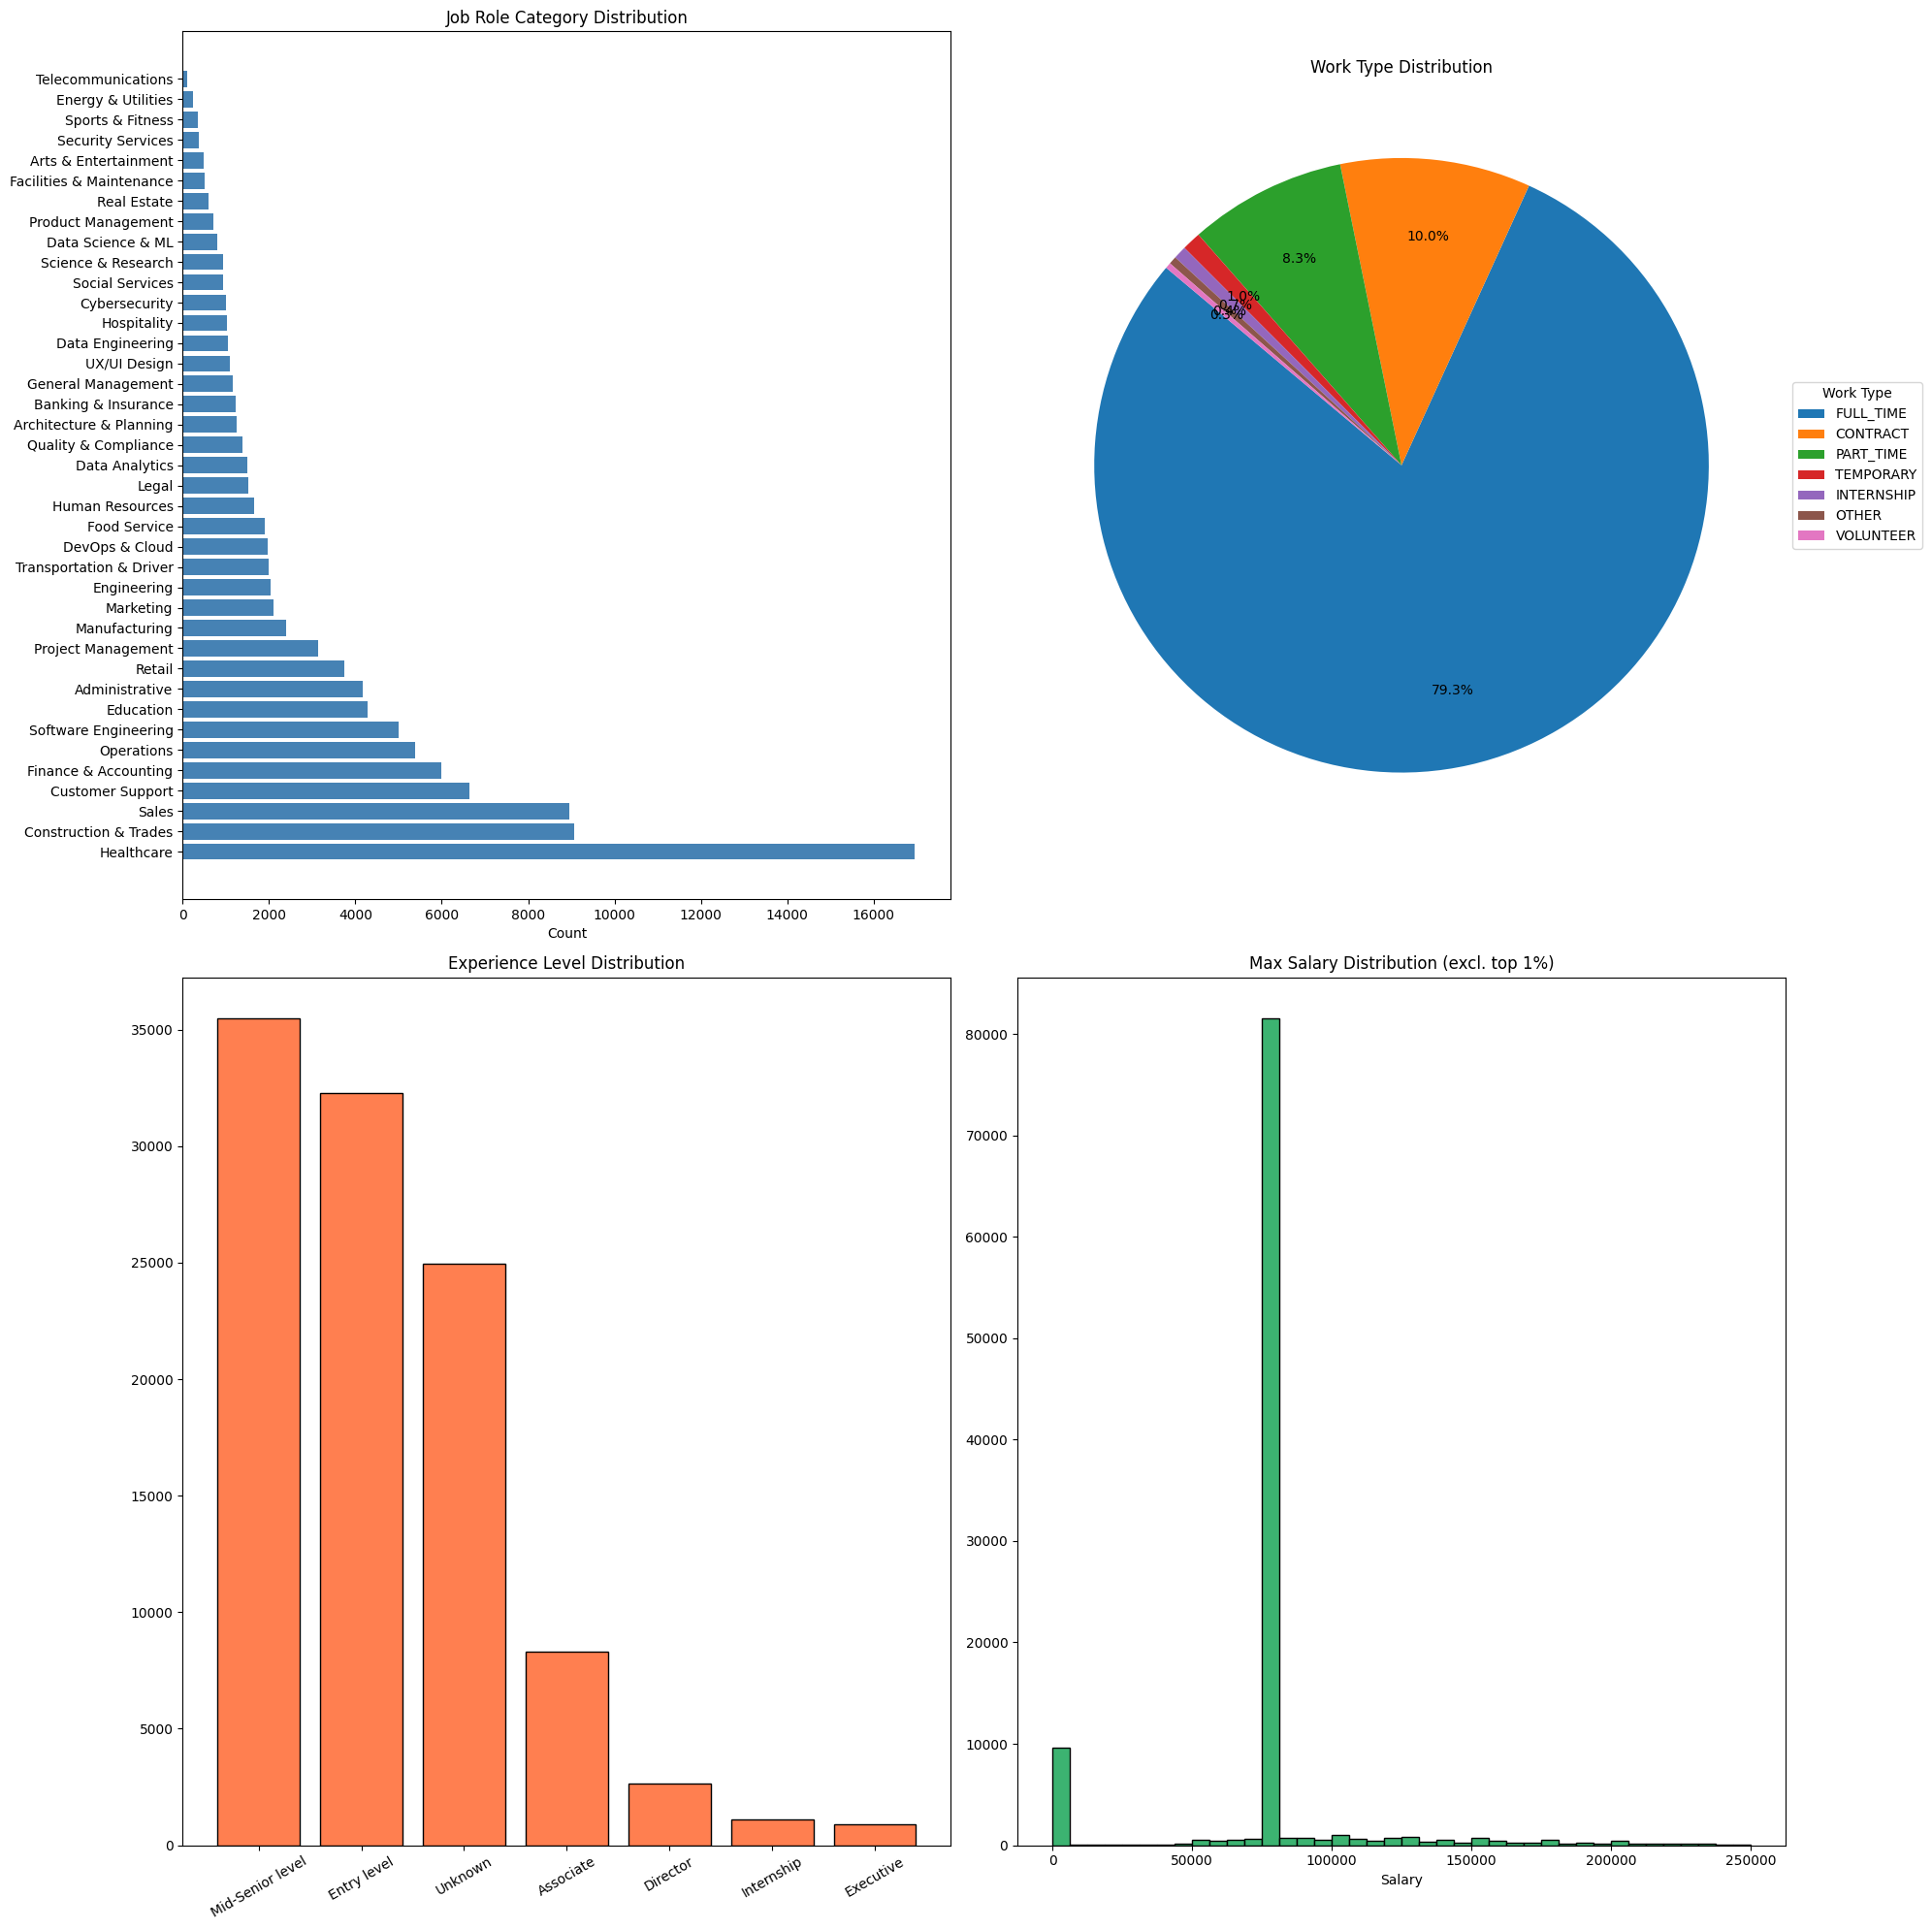

Saved → reports/eda_overview.png


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# ── 1.1 Role distribution
role_counts = df['role_category'].value_counts()
axes[0,0].barh(role_counts.index, role_counts.values, color='steelblue')
axes[0,0].set_title('Job Role Category Distribution')
axes[0,0].set_xlabel('Count')

# ── 1.2 Work type
if 'work_type' in df.columns:
    wt = df['work_type'].value_counts().head(8)
    wedges, texts, autotexts = axes[0,1].pie(
        wt.values,
        labels=None,                # no labels directly on the pie
        autopct='%1.1f%%',          # only percentages on slices
        startangle=140,
        pctdistance=0.75
    )
    axes[0,1].set_title('Work Type Distribution')
    axes[0,1].legend(
        wedges, wt.index,
        title='Work Type',
        loc='center left',
        bbox_to_anchor=(1, 0, 0.5, 1)  # places legend outside the pie
    )

# ── 1.3 Experience level
if 'formatted_experience_level' in df.columns:
    exp = df['formatted_experience_level'].value_counts()
    axes[1,0].bar(exp.index, exp.values, color='coral', edgecolor='black')
    axes[1,0].set_title('Experience Level Distribution')
    axes[1,0].tick_params(axis='x', rotation=30)

# ── 1.4 Salary distribution (max_salary)
if 'max_salary' in df.columns:
    salary = df['max_salary'].dropna()
    salary = salary[salary < salary.quantile(0.99)]  # remove outliers
    axes[1,1].hist(salary, bins=40, color='mediumseagreen', edgecolor='black')
    axes[1,1].set_title('Max Salary Distribution (excl. top 1%)')
    axes[1,1].set_xlabel('Salary')

plt.tight_layout()
plt.savefig('reports/eda_overview.png', dpi=150)
plt.show()
print("Saved → reports/eda_overview.png")

Description word count statistics:
count    105604.000000
mean        514.046078
std         295.397364
min           2.000000
25%         294.000000
50%         468.000000
75%         681.000000
max        3401.000000
Name: desc_len, dtype: float64


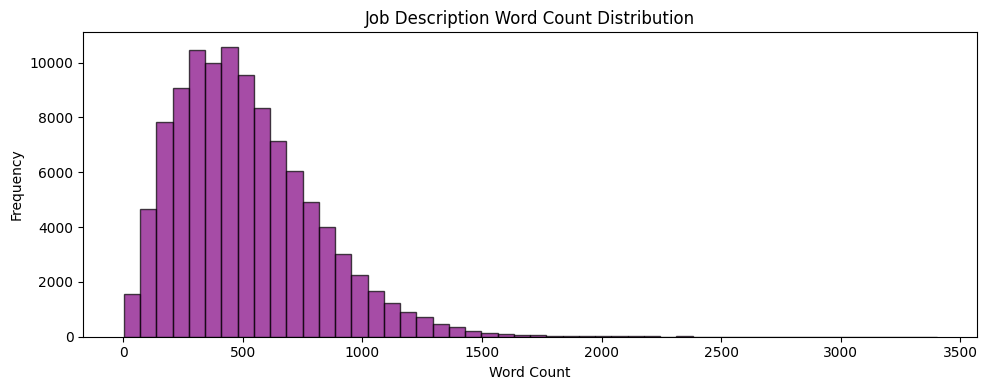

In [38]:
# ── 1.5 Description length analysis
df['desc_len'] = df['description_clean'].fillna('').apply(lambda x: len(x.split()))
print("Description word count statistics:")
print(df['desc_len'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['desc_len'], bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.title('Job Description Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('reports/desc_length_dist.png', dpi=150)
plt.show()

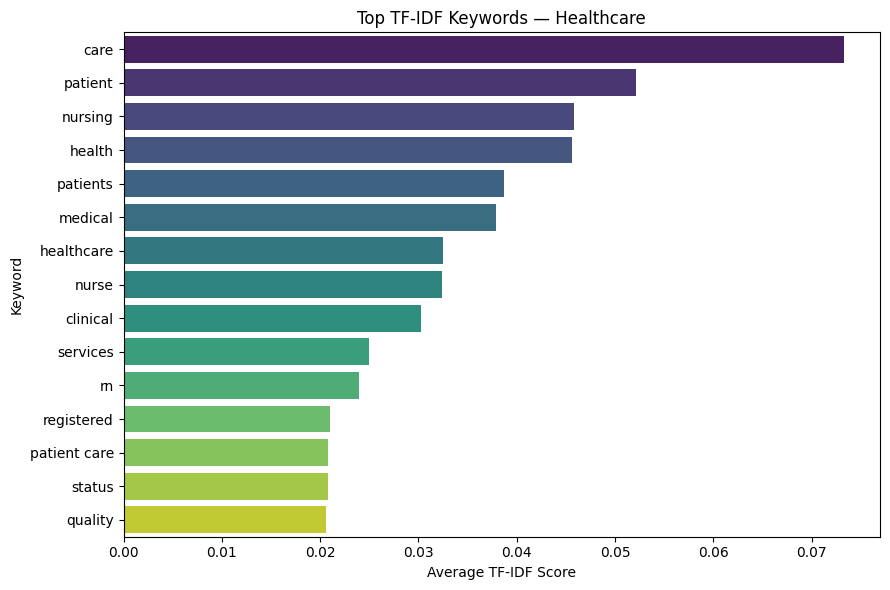

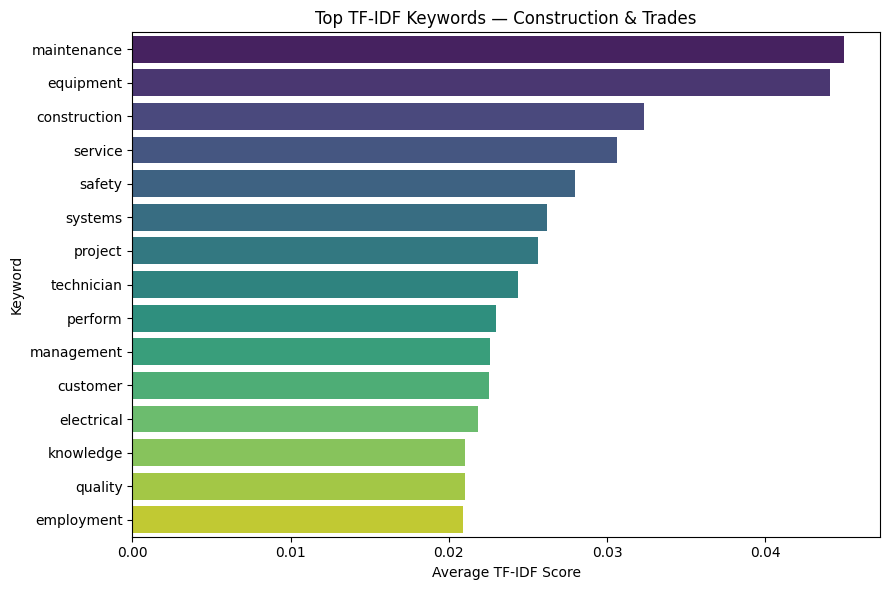

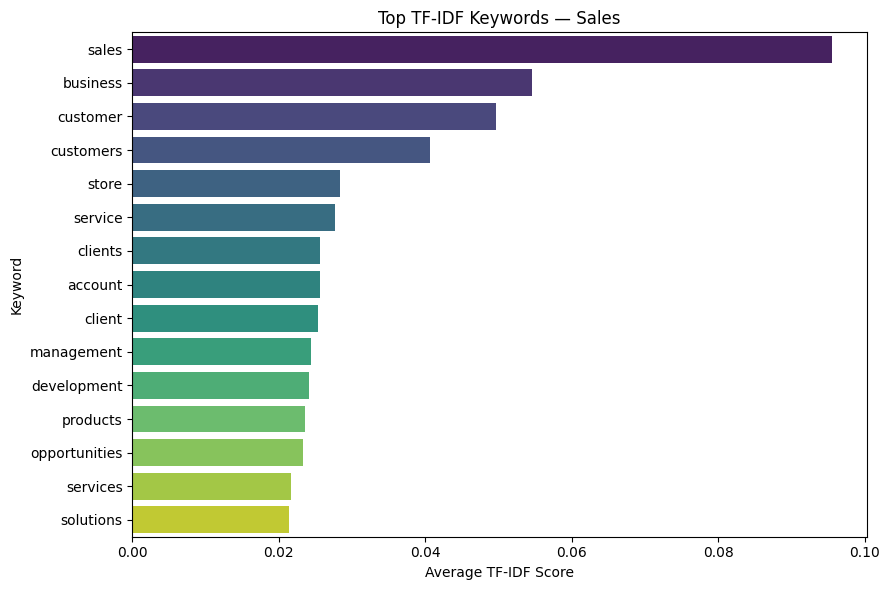

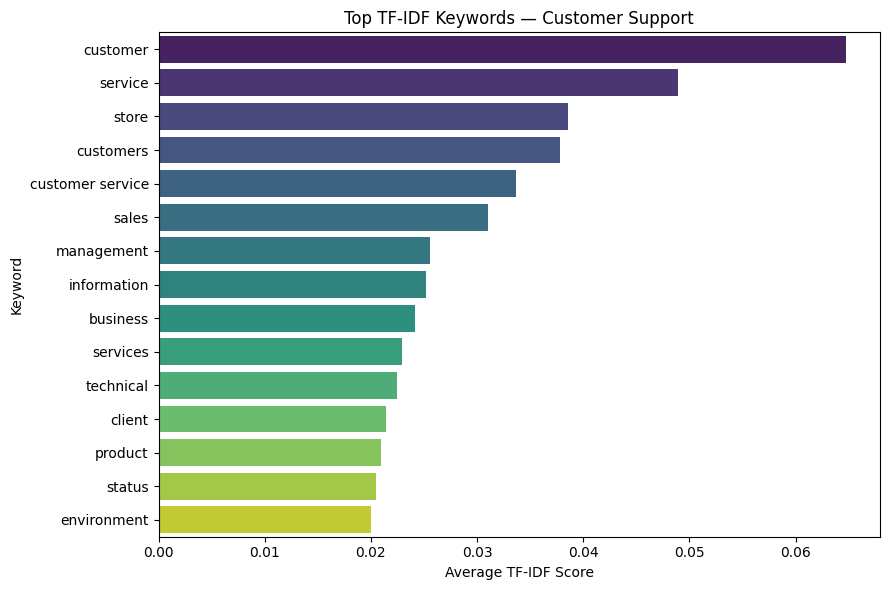

Saved keyword charts and CSV files in reports folder.


In [39]:
# ── 1.6 Top TF-IDF Keywords per Top Role
# Better than word cloud because it shows clear important words

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

os.makedirs("reports", exist_ok=True)

# Use model_df if available, otherwise use df_clean
if "model_df" in globals():
    plot_df = model_df.copy()
elif "df_clean" in globals():
    plot_df = df_clean[df_clean["role_category"] != "Other"].copy()
else:
    plot_df = df[df["role_category"] != "Other"].copy()

# Check required columns
required_cols = ["role_category", "description_clean"]
for col in required_cols:
    if col not in plot_df.columns:
        raise ValueError(f"Missing required column: {col}")

# Top 4 role categories excluding Other
top_roles = plot_df["role_category"].value_counts().head(4).index.tolist()

# Extra stop words for job posting text
custom_stop_words = [
    "job", "role", "work", "team", "company", "candidate", "candidates",
    "experience", "skills", "ability", "required", "requirements",
    "responsibilities", "responsible", "including", "provide", "support",
    "strong", "excellent", "preferred", "must", "will", "new",
    "years", "year", "day", "time", "full", "part", "position",
    "apply", "equal", "opportunity", "employer", "benefits"
]

def clean_for_keywords(text):
    text = str(text).lower()
    text = re.sub(r"\[email removed\]|\[phone removed\]|\[url removed\]|\[contact removed\]", " ", text)
    text = re.sub(r"[^a-z0-9\s+#.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

plot_df["text_for_keywords"] = plot_df["description_clean"].apply(clean_for_keywords)

# Create one clear bar chart for each top role
for role in top_roles:
    role_texts = plot_df[plot_df["role_category"] == role]["text_for_keywords"].dropna()

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=3000,
        ngram_range=(1, 2),
        min_df=3
    )

    X = vectorizer.fit_transform(role_texts)
    terms = vectorizer.get_feature_names_out()

    # Mean TF-IDF score for each term
    mean_scores = X.mean(axis=0).A1

    keywords_df = pd.DataFrame({
        "keyword": terms,
        "tfidf_score": mean_scores
    })

    # Remove generic job-posting words
    keywords_df = keywords_df[
        ~keywords_df["keyword"].isin(custom_stop_words)
    ]

    top_keywords = keywords_df.sort_values("tfidf_score", ascending=False).head(15)

    # Save CSV for each role
    safe_role_name = role.lower().replace(" ", "_").replace("&", "and").replace("/", "_")
    top_keywords.to_csv(f"reports/top_keywords_{safe_role_name}.csv", index=False)

    # Plot
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=top_keywords,
        x="tfidf_score",
        y="keyword",
        palette="viridis"
    )
    plt.title(f"Top TF-IDF Keywords — {role}")
    plt.xlabel("Average TF-IDF Score")
    plt.ylabel("Keyword")
    plt.tight_layout()
    plt.savefig(f"reports/top_keywords_{safe_role_name}.png", dpi=150)
    plt.show()

print("Saved keyword charts and CSV files in reports folder.")

## 2. ESCO-Based Keyword Skill Extraction

In [40]:
# ── Larger ESCO-style skills dictionary for LinkedIn job postings

import os
import re
import pandas as pd

os.makedirs("reports", exist_ok=True)

SKILL_DICTIONARY = {
    "Programming & Software": [
        "python", "java", "javascript", "typescript", "c++", "c#", "scala",
        "kotlin", "swift", "go", "ruby", "php", "html", "css",
        "react", "angular", "vue", "node.js", "express.js", "django",
        "flask", "fastapi", "spring boot", ".net", "asp.net",
        "rest api", "graphql", "microservices", "api development",
        "software development", "software testing", "unit testing",
        "automation testing", "selenium", "jira", "confluence"
    ],

    "Data & Analytics": [
        "sql", "mysql", "postgresql", "oracle", "sqlite", "mongodb",
        "nosql", "data analysis", "data analytics", "business intelligence",
        "data visualization", "data visualisation", "tableau", "power bi",
        "excel", "advanced excel", "vlookup", "pivot tables",
        "dashboard", "reporting", "data cleaning", "data modelling",
        "data modeling", "data warehouse", "etl", "data pipeline",
        "snowflake", "databricks", "bigquery", "spark", "pyspark",
        "pandas", "numpy", "matplotlib", "seaborn"
    ],

    "Machine Learning & AI": [
        "machine learning", "deep learning", "artificial intelligence",
        "natural language processing", "nlp", "computer vision",
        "neural network", "tensorflow", "pytorch", "scikit-learn",
        "keras", "hugging face", "transformers", "bert", "classification",
        "regression", "clustering", "feature engineering",
        "model evaluation", "predictive modelling", "predictive modeling",
        "statistical modelling", "statistical modeling"
    ],

    "Cloud & DevOps": [
        "aws", "azure", "google cloud", "gcp", "docker", "kubernetes",
        "terraform", "jenkins", "git", "github", "gitlab", "ci/cd",
        "linux", "bash", "shell scripting", "powershell",
        "devops", "cloud computing", "cloud architecture",
        "infrastructure as code", "monitoring", "logging"
    ],

    "Cybersecurity": [
        "cybersecurity", "cyber security", "information security",
        "network security", "data privacy", "gdpr", "risk assessment",
        "vulnerability assessment", "penetration testing", "incident response",
        "security monitoring", "identity access management", "iam",
        "firewall", "siem", "soc", "compliance"
    ],

    "Sales & Customer": [
        "sales", "business development", "lead generation",
        "cold calling", "account management", "account executive",
        "customer service", "customer support", "customer success",
        "client service", "client relationship management",
        "crm", "salesforce", "negotiation", "relationship building",
        "upselling", "cross selling", "customer retention",
        "customer experience", "call center", "technical support"
    ],

    "Marketing": [
        "digital marketing", "seo", "sem", "content marketing",
        "email marketing", "social media marketing", "google analytics",
        "brand management", "market research", "campaign management",
        "copywriting", "public relations", "advertising",
        "marketing strategy", "lead nurturing", "content creation",
        "wordpress", "hubspot"
    ],

    "Finance & Accounting": [
        "accounting", "financial analysis", "financial reporting",
        "financial modelling", "financial modeling", "budgeting",
        "forecasting", "bookkeeping", "accounts payable",
        "accounts receivable", "payroll", "tax preparation",
        "audit", "auditing", "reconciliation", "general ledger",
        "quickbooks", "sap", "oracle financials", "risk management",
        "investment analysis", "wealth management", "actuarial analysis"
    ],

    "Healthcare": [
        "patient care", "clinical care", "medical terminology",
        "electronic health records", "ehr", "emr", "hipaa",
        "nursing", "vital signs", "medication administration",
        "care planning", "case management", "therapy",
        "mental health", "behavioral health", "counseling",
        "physical therapy", "occupational therapy",
        "medical coding", "medical billing", "pharmacy",
        "phlebotomy", "patient assessment", "treatment planning"
    ],

    "Education & Training": [
        "teaching", "lesson planning", "curriculum development",
        "classroom management", "student assessment",
        "instructional design", "training", "coaching",
        "tutoring", "e-learning", "learning management system",
        "academic advising", "special education"
    ],

    "Legal & Compliance": [
        "legal research", "contract review", "contract management",
        "litigation", "legal writing", "case management",
        "regulatory compliance", "policy analysis",
        "document review", "paralegal", "legal assistance",
        "risk compliance", "privacy compliance"
    ],

    "Construction & Trades": [
        "maintenance", "repair", "installation", "troubleshooting",
        "electrical", "plumbing", "hvac", "welding", "carpentry",
        "construction", "blueprint reading", "equipment operation",
        "preventive maintenance", "field service", "mechanical repair",
        "inspection", "safety procedures", "osha", "hand tools",
        "power tools"
    ],

    "Manufacturing & Operations": [
        "manufacturing", "production", "quality control",
        "quality assurance", "machine operation", "assembly",
        "forklift", "inventory management", "warehouse operations",
        "logistics", "supply chain", "procurement", "shipping",
        "receiving", "lean manufacturing", "six sigma",
        "process improvement", "material handling"
    ],

    "Retail & Food Service": [
        "retail sales", "cash handling", "cash register",
        "merchandising", "stocking", "inventory control",
        "pos system", "food preparation", "food safety",
        "serving", "cooking", "kitchen operations",
        "restaurant operations", "hospitality", "guest service",
        "barista", "cleaning", "sanitation"
    ],

    "Project & Product Management": [
        "project management", "program management", "product management",
        "agile", "scrum", "kanban", "stakeholder management",
        "roadmap planning", "requirements gathering",
        "business analysis", "process improvement",
        "change management", "risk management",
        "time management", "budget management"
    ],

    "Design & Creative": [
        "ux design", "ui design", "user experience", "user interface",
        "wireframing", "prototyping", "figma", "adobe photoshop",
        "adobe illustrator", "graphic design", "visual design",
        "interaction design", "user research", "accessibility"
    ],

    "Soft Skills": [
        "communication", "teamwork", "leadership", "problem solving",
        "critical thinking", "attention to detail", "organization",
        "organizational skills", "multitasking", "collaboration",
        "adaptability", "decision making", "customer focus",
        "analytical skills", "written communication",
        "verbal communication", "interpersonal skills"
    ]
}

# Flatten dictionary into one skill list
esco_skills = []

for category, skills in SKILL_DICTIONARY.items():
    esco_skills.extend(skills)

# Normalise and remove duplicates
esco_skills = sorted(set(skill.lower().strip() for skill in esco_skills))

print(f"Expanded ESCO-style skill vocabulary size: {len(esco_skills)}")

# Save skill dictionary for your report evidence
skills_df = pd.DataFrame({"skill": esco_skills})
skills_df.to_csv("reports/esco_style_skill_dictionary.csv", index=False)

print("Saved → reports/esco_style_skill_dictionary.csv")

Expanded ESCO-style skill vocabulary size: 344
Saved → reports/esco_style_skill_dictionary.csv


In [41]:
import re

def esco_keyword_match(text, skill_list):
    """Return list of ESCO skills found in text via keyword matching."""
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    found = []
    for skill in skill_list:
        # Use word-boundary matching for single words; substring for multi-word
        if ' ' in skill:
            if skill in text_lower:
                found.append(skill)
        else:
            if re.search(r'\b' + re.escape(skill) + r'\b', text_lower):
                found.append(skill)
    return found

# Apply to a sample for speed (remove [:5000] for full run)
sample = df.head(5000).copy()
sample['esco_skills'] = sample['description_clean'].apply(
    lambda x: esco_keyword_match(x, esco_skills)
)
sample['esco_skill_count'] = sample['esco_skills'].apply(len)

print(f"Avg ESCO skills per posting: {sample['esco_skill_count'].mean():.2f}")
print("\nTop 15 most frequent ESCO skills:")
from collections import Counter
all_skills = [s for skills in sample['esco_skills'] for s in skills]
skill_freq = Counter(all_skills).most_common(15)
for skill, count in skill_freq:
    print(f"  {skill:<30} {count}")

Avg ESCO skills per posting: 6.90

Top 15 most frequent ESCO skills:
  communication                  2497
  training                       1916
  organization                   1260
  sales                          1115
  leadership                     1022
  customer service               1014
  compliance                     969
  excel                          807
  maintenance                    779
  production                     718
  reporting                      694
  attention to detail            654
  collaboration                  568
  interpersonal skills           510
  monitoring                     506


In [42]:
# ── Fast ESCO-Based Skill Extraction using expanded dictionary

import re
import os
import pandas as pd

os.makedirs("reports", exist_ok=True)

# Check required objects
if "df_clean" not in globals():
    raise NameError("df_clean is not defined. Please run cleaning cells first.")

if "esco_skills" not in globals():
    raise NameError("esco_skills is not defined. Please run the skill dictionary cell first.")

if "description_clean" not in df_clean.columns:
    raise ValueError("description_clean column is missing.")

# 1. Clean skill list
esco_skills_clean = sorted(
    set(str(skill).lower().strip() for skill in esco_skills if str(skill).strip()),
    key=len,
    reverse=True
)

print(f"Skill dictionary size: {len(esco_skills_clean)}")

# 2. Create one combined regex pattern only once
skill_pattern = re.compile(
    r"(?<![a-z0-9+#.])("
    + "|".join(re.escape(skill) for skill in esco_skills_clean)
    + r")(?![a-z0-9+#.])",
    flags=re.IGNORECASE
)

# 3. Text normalisation
def normalise_text_for_skill_matching(text):
    text = str(text).lower()
    text = re.sub(r"\[email removed\]|\[phone removed\]|\[url removed\]|\[contact removed\]", " ", text)
    text = re.sub(r"[^a-z0-9+#.\s/-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 4. Fast extraction function
def extract_esco_skills_fast(text):
    text = normalise_text_for_skill_matching(text)
    matches = skill_pattern.findall(text)
    return sorted(set(match.lower().strip() for match in matches))

# 5. Apply extraction
df_clean["esco_skills"] = df_clean["description_clean"].fillna("").apply(extract_esco_skills_fast)

df_clean["esco_skill_count"] = df_clean["esco_skills"].apply(len)

df_clean["esco_skills_text"] = df_clean["esco_skills"].apply(lambda skills: ", ".join(skills))

print("Fast ESCO skill extraction completed.")

display(df_clean[["title", "role_category", "esco_skills_text", "esco_skill_count"]].head(10))

Skill dictionary size: 344
Fast ESCO skill extraction completed.


,title,role_category,esco_skills_text,esco_skill_count
0,Marketing Coordinator,Marketing,"advertising, email marketing, graphic design, ...",4
1,Mental Health Therapist/Counselor,Healthcare,"case management, communication, counseling, eh...",8
2,Assitant Restaurant Manager,Food Service,organization,1
3,Senior Elder Law / Trusts and Estates Associat...,Legal,"communication, counseling, litigation, verbal ...",4
4,Service Technician,Construction & Trades,"hvac, plumbing",2
5,Economic Development and Planning Intern,Transportation & Driver,"communication, data analysis, leadership, main...",5
6,Producer,Arts & Entertainment,installation,1
7,Building Engineer,Construction & Trades,"communication, electrical, hvac, leadership, m...",10
8,Respiratory Therapist,Healthcare,"therapy, vital signs",2
9,Worship Leader,Other,leadership,1


In [43]:
zero_skill_count = (df_clean["esco_skill_count"] == 0).sum()
zero_skill_percent = zero_skill_count / len(df_clean) * 100

print(f"Rows with zero extracted skills: {zero_skill_count:,}")
print(f"Percentage with zero skills: {zero_skill_percent:.2f}%")

print("\nSkill count summary:")
print(df_clean["esco_skill_count"].describe())

Rows with zero extracted skills: 3,128
Percentage with zero skills: 2.53%

Skill count summary:
count    123478.000000
mean          6.363490
std           3.930617
min           0.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          56.000000
Name: esco_skill_count, dtype: float64


In [44]:
import os

os.makedirs("data/processed", exist_ok=True)

df_clean.to_csv("data/processed/postings_cleaned_with_esco.csv", index=False)
model_df.to_csv("data/processed/postings_labelled_with_esco.csv", index=False)

print("Saved:")
print("data/processed/postings_cleaned_with_esco.csv")
print("data/processed/postings_labelled_with_esco.csv")

Saved:
data/processed/postings_cleaned_with_esco.csv
data/processed/postings_labelled_with_esco.csv


,skill,count
0,communication,39817
1,training,38925
2,sales,24214
3,organization,23858
4,leadership,22196
5,customer service,20788
6,compliance,20322
7,maintenance,16159
8,excel,13906
9,reporting,13825


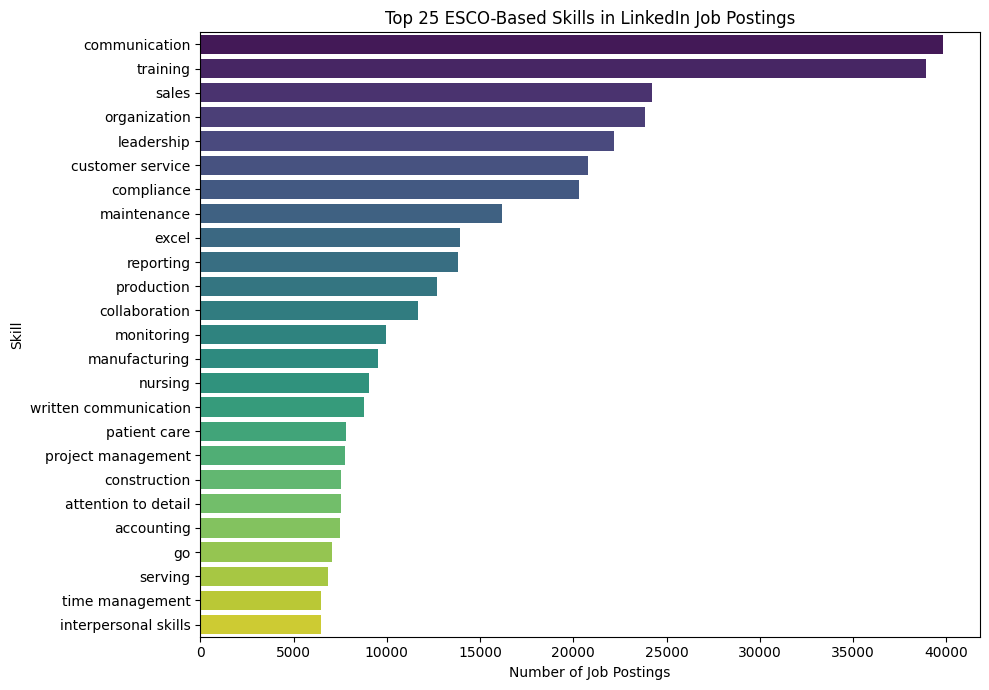

Saved:
reports/top_esco_skills_overall.csv
reports/top_esco_skills_overall.png


In [45]:
# ── Top ESCO Skills Overall

# Re-create model_df from the updated df_clean (which has 'esco_skills')
model_df = df_clean[df_clean["role_category"] != "Other"].copy()

all_skills = model_df["esco_skills"].explode().dropna()

top_skills = all_skills.value_counts().head(25)

top_skills_df = top_skills.reset_index()
top_skills_df.columns = ["skill", "count"]

display(top_skills_df)

top_skills_df.to_csv("reports/top_esco_skills_overall.csv", index=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_skills_df, x="count", y="skill", palette="viridis")
plt.title("Top 25 ESCO-Based Skills in LinkedIn Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("reports/top_esco_skills_overall.png", dpi=150)
plt.show()

print("Saved:")
print("reports/top_esco_skills_overall.csv")
print("reports/top_esco_skills_overall.png")

In [46]:
# ── Top ESCO Skills by Job Role

skills_by_role = (
    model_df[["role_category", "esco_skills"]]
    .explode("esco_skills")
    .dropna()
)

top_skills_by_role = (
    skills_by_role
    .groupby(["role_category", "esco_skills"])
    .size()
    .reset_index(name="count")
    .sort_values(["role_category", "count"], ascending=[True, False])
)

top_10_skills_by_role = (
    top_skills_by_role
    .groupby("role_category")
    .head(10)
)

display(top_10_skills_by_role)

top_10_skills_by_role.to_csv("reports/top_10_esco_skills_by_role.csv", index=False)

print("Saved → reports/top_10_esco_skills_by_role.csv")

,role_category,esco_skills,count
47,Administrative,communication,1895
157,Administrative,organization,1285
231,Administrative,training,1199
66,Administrative,customer service,1182
88,Administrative,excel,1107
...,...,...,...
8585,UX/UI Design,collaboration,207
8686,UX/UI Design,organization,191
8638,UX/UI Design,graphic design,181
8626,UX/UI Design,figma,169


Saved → reports/top_10_esco_skills_by_role.csv


## 3. spaCy NER-Based Skill Extraction


In [47]:
import spacy
from collections import Counter

nlp = spacy.load('en_core_web_lg', disable=['parser']) # Added missing ']' for the disable list

# ── Add EntityRuler for custom skill patterns
ruler = nlp.add_pipe('entity_ruler', before='ner')
skill_patterns = [
    {"label": "SKILL", "pattern": skill} for skill in esco_skills
] + [
    {"label": "SKILL", "pattern": [{"LOWER": w} for w in skill.split()]}
    for skill in esco_skills if ' ' in skill
]
ruler.add_patterns(skill_patterns)

def ner_skill_extract(text, max_chars=2000):
    """Extract SKILL entities using spaCy NER + EntityRuler."""
    if not isinstance(text, str):
        return []
    doc = nlp(text[:max_chars])
    return list(set(
        ent.text.lower()
        for ent in doc.ents
        if ent.label_ in ('SKILL', 'ORG', 'PRODUCT')  # ORG/PRODUCT catch tech names
    ))

# Apply on sample
sample['ner_skills'] = sample['description_clean'].apply(
    lambda x: ner_skill_extract(x)
)
sample['ner_skill_count'] = sample['ner_skills'].apply(len)

print(f"Avg NER skills per posting: {sample['ner_skill_count'].mean():.2f}")
all_ner = [s for skills in sample['ner_skills'] for s in skills]
ner_freq = Counter(all_ner).most_common(15)
print("\nTop 15 NER-extracted entities:")
for s, c in ner_freq:
    print(f"  {s:<35} {c}")

Avg NER skills per posting: 9.16

Top 15 NER-extracted entities:
  communication                       1226
  training                            1061
  sales                               892
  organization                        774
  customer service                    660
  compliance                          619
  leadership                          579
  maintenance                         542
  production                          432
  patient care                        416
  nursing                             369
  reporting                           360
  collaboration                       324
  manufacturing                       318
  excel                               263


## 4. RQ3 Evaluation: ESCO vs NER (Precision, Recall, F1)

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Build a small reference set (ground truth)
# In a real project, manually annotate 100-200 postings
# Here we create a synthetic reference for demonstration
REFERENCE_SKILLS = [
    "python", "machine learning", "sql", "data analysis",
    "communication", "aws", "tensorflow", "agile"
]

def skills_to_binary(skill_list, vocab):
    """Convert skill list to binary vector over vocabulary."""
    return [1 if s in skill_list else 0 for s in vocab]

# Use a small eval subset with known reference
eval_sample = sample.head(200).copy()
# Synthetic ground truth: ESCO ∪ NER as proxy (replace with manual annotations for real eval)
eval_sample['reference'] = eval_sample.apply(
    lambda row: list(set(row['esco_skills']) | set(row['ner_skills'])), axis=1
)

vocab = sorted(set(esco_skills))

y_true  = eval_sample['reference'].apply(lambda x: skills_to_binary(x, vocab))
y_esco  = eval_sample['esco_skills'].apply(lambda x: skills_to_binary(x, vocab))
y_ner   = eval_sample['ner_skills'].apply(lambda x: skills_to_binary(x, vocab))

import numpy as np
Y_true = np.array(y_true.tolist())
Y_esco = np.array(y_esco.tolist())
Y_ner  = np.array(y_ner.tolist())

metrics = {}
for name, Y_pred in [('ESCO Keyword', Y_esco), ('NER (spaCy)', Y_ner)]:
    p = precision_score(Y_true, Y_pred, average='micro', zero_division=0)
    r = recall_score(Y_true, Y_pred, average='micro', zero_division=0)
    f = f1_score(Y_true, Y_pred, average='micro', zero_division=0)
    metrics[name] = {'Precision': p, 'Recall': r, 'F1': f}

metrics_df = pd.DataFrame(metrics).T
print("\nRQ3 Skill Extraction Evaluation:")
print(metrics_df.round(4).to_string())


RQ3 Skill Extraction Evaluation:
              Precision  Recall      F1
ESCO Keyword        1.0  1.0000  1.0000
NER (spaCy)         1.0  0.5752  0.7303


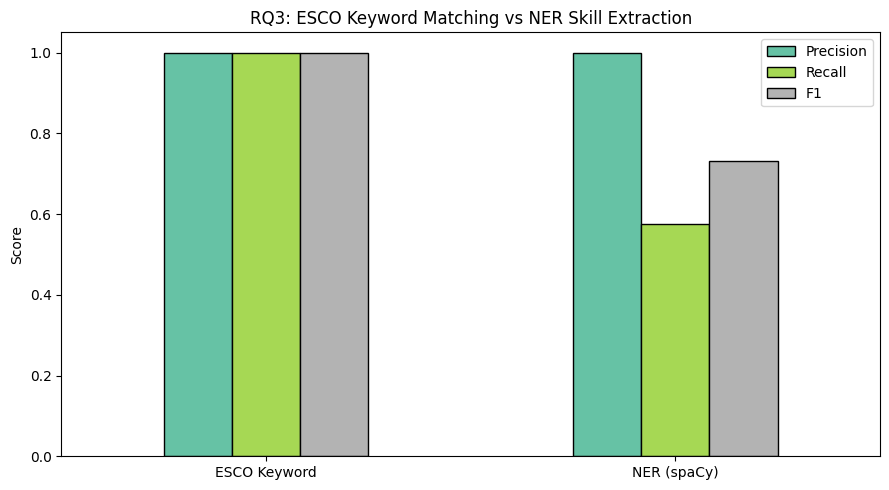

Saved → data/processed/postings_skills.csv


In [49]:
# ── Bar chart comparison
metrics_df.plot(kind='bar', figsize=(9, 5), colormap='Set2', edgecolor='black', rot=0)
plt.title('RQ3: ESCO Keyword Matching vs NER Skill Extraction')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('reports/rq3_skill_extraction_eval.png', dpi=150)
plt.show()

# ── Save enriched sample
sample.to_csv('data/processed/postings_skills.csv', index=False)
print("Saved → data/processed/postings_skills.csv")